# **Algoritmo de Schnorr de Factorización mediante QAOA a través de Qiskit (2)**

Implementación del Algoritmo de Schnorr al igual que la primera parte.

En este notebook se realizará la reducción LLL mediante el módulo fpylll

## **1. Algoritmo de Schnorr**

### **Definición de una instancia del CVP**

In [1]:
# Realizo los imports
import numpy as np
from fpylll import IntegerMatrix, LLL, GSO
from copy import deepcopy
import sympy
from scipy.optimize import minimize


# Time keeping.
import time

# Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

In [2]:
primes = [2,3,5,7,11,13,17,19,23,29,31,37,41,43,47,53,59,61,67,71,73,79,83,89,97,101,103,107,109,113,127,131,137,139,149,151,157,163,167,173,179,181,191,193,197,199,211,223,227,229,233,239,241,251,257,263,269,271,277,281,283,293,307,311,313,317,331,337,347,349,353,359,367,373,379,383,389,397,401,409,419,421,431,433,439,443,449,457,461,463,467,479,487,491,499,503,509,521,523,541,547,557,563,569,571,577,587,593,599,601,607,613,617,619,631,641,643,647,653,659,661,673,677,683,691,701,709,719,727,733,739,743,751,757,761,769,773,787,797,809,811,821,823,827,829,839,853,857,859,863,877,881,883,887,907,911,919,929,937,941,947,953,967,971,977,983,991,997,1009,1013,1019,1021,1031,1033,1039,1049,1051,1061,1063,1069,1087,1091,1093,1097,1103,1109,1117,1123,1129,1151,1153,1163,1171,1181,1187,1193,1201,1213,1217,1223,1229,1231,1237,1249,1259,1277,1279,1283,1289,1291,1297,1301,1303,1307,1319,1321,1327,1361,1367,1373,1381,1399,1409,1423,1427,1429,1433,1439,1447,1451,1453,1459,1471,1481,1483,1487,1489,1493,1499,1511,1523,1531,1543,1549,1553,1559,1567,1571,1579,1583,1597,1601,1607,1609,1613,1619,1621,1627,1637,1657,1663,1667,1669,1693,1697,1699,1709,1721,1723,1733,1741,1747,1753,1759,1777,1783,1787,1789,1801,1811,1823,1831,1847,1861,1867,1871,1873,1877,1879,1889,1901,1907,1913,1931,1933,1949,1951,1973,1979,1987,1993,1997,1999,2003,2011,2017,2027,2029,2039,2053,2063,2069,2081,2083,2087,2089,2099,2111,2113,2129,2131,2137,2141,2143,2153,2161,2179,2203,2207,2213,2221,2237,2239,2243,2251,2267,2269,2273,2281,2287,2293,2297,2309,2311,2333,2339,2341,2347,2351,2357,2371,2377,2381,2383,2389,2393,2399,2411,2417,2423,2437,2441,2447,2459,2467,2473,2477,2503,2521,2531,2539,2543,2549,2551,2557,2579,2591,2593,2609,2617,2621,2633,2647,2657,2659,2663,2671,2677,2683,2687,2689,2693,2699,2707,2711,2713,2719,2729,2731,2741,2749,2753,2767,2777,2789,2791,2797,2801,2803,2819,2833,2837,2843,2851,2857,2861,2879,2887,2897,2903,2909,2917,2927,2939,2953,2957,2963,2969,2971,2999,3001,3011,3019,3023,3037,3041,3049,3061,3067,3079,3083,3089,3109,3119,3121,3137,3163,3167,3169,3181,3187,3191,3203,3209,3217,3221,3229,3251,3253,3257,3259,3271,3299,3301,3307,3313,3319,3323,3329,3331,3343,3347,3359,3361,3371,3373,3389,3391,3407,3413,3433,3449,3457,3461,3463,3467,3469,3491,3499,3511,3517,3527,3529,3533,3539,3541,3547,3557,3559,3571,3581,3583,3593,3607,3613,3617,3623,3631,3637,3643,3659,3671,3673,3677,3691,3697,3701,3709,3719,3727,3733,3739,3761,3767,3769,3779,3793,3797,3803,3821,3823,3833,3847,3851,3853,3863,3877,3881,3889,3907,3911,3917,3919,3923,3929,3931,3943,3947,3967,3989,4001,4003,4007,4013,4019,4021,4027,4049,4051,4057,4073,4079,4091,4093,4099,4111,4127,4129,4133,4139,4153,4157,4159,4177,4201,4211,4217,4219,4229,4231,4241,4243,4253,4259,4261,4271,4273,4283,4289,4297,4327,4337,4339,4349,4357,4363,4373,4391,4397,4409,4421,4423,4441,4447,4451,4457,4463,4481,4483,4493,4507,4513,4517,4519,4523,4547,4549,4561,4567,4583,4591,4597,4603,4621,4637,4639,4643,4649,4651,4657,4663,4673,4679,4691,4703,4721,4723,4729,4733,4751,4759,4783,4787,4789,4793,4799,4801,4813,4817,4831,4861,4871,4877,4889,4903,4909,4919,4931,4933,4937,4943,4951,4957,4967,4969,4973,4987,4993,4999,5003,5009,5011,5021,5023,5039,5051,5059,5077,5081,5087,5099,5101,5107,5113,5119,5147,5153,5167,5171,5179,5189,5197,5209,5227,5231,5233,5237,5261,5273,5279,5281,5297,5303,5309,5323,5333,5347,5351,5381,5387,5393,5399,5407,5413,5417,5419,5431,5437,5441,5443,5449,5471,5477,5479,5483,5501,5503,5507,5519,5521,5527,5531,5557,5563,5569,5573,5581,5591,5623,5639,5641,5647,5651,5653,5657,5659,5669,5683,5689,5693,5701,5711,5717,5737,5741,5743,5749,5779,5783,5791,5801,5807,5813,5821,5827,5839,5843,5849,5851,5857,5861,5867,5869,5879,5881,5897,5903,5923,5927,5939,5953,5981,5987,6007,6011,6029,6037,6043,6047,6053,6067,6073,6079,6089,6091,6101,6113,6121,6131,6133,6143,6151,6163,6173,6197,6199,6203,6211,6217,6221,6229,6247,6257,6263,6269,6271,6277,6287,6299,6301,6311,6317,6323,6329,6337,6343,6353,6359,6361,6367,6373,6379,6389,6397,6421,6427,6449,6451,6469,6473,6481,6491,6521,6529,6547,6551,6553,6563,6569,6571,6577,6581,6599,6607,6619,6637,6653,6659,6661,6673,6679,6689,6691,6701,6703,6709,6719,6733,6737,6761,6763,6779,6781,6791,6793,6803,6823,6827,6829,6833,6841,6857,6863,6869,6871,6883,6899,6907,6911,6917,6947,6949,6959,6961,6967,6971,6977,6983,6991,6997,7001,7013,7019,7027,7039,7043,7057,7069,7079,7103,7109,7121,7127,7129,7151,7159,7177,7187,7193,7207,7211,7213,7219,7229,7237,7243,7247,7253,7283,7297,7307,7309,7321,7331,7333,7349,7351,7369,7393,7411,7417,7433,7451,7457,7459,7477,7481,7487,7489,7499,7507,7517,7523,7529,7537,7541,7547,7549,7559,7561,7573,7577,7583,7589,7591,7603,7607,7621,7639,7643,7649,7669,7673,7681,7687,7691,7699,7703,7717,7723,7727,7741,7753,7757,7759,7789,7793,7817,7823,7829,7841,7853,7867,7873,7877,7879,7883,7901,7907,7919]

In [3]:
N = 48567227 
seed = 99

c = 4 #parametro de precision

l = 1 #parametro del reticulo

np.random.seed(seed)

#Calculamos el numero de bits m de N

m = np.round(np.log2(N)).astype(int)

# n es la dimension del reticulo 
n = np.round(l * m // np.log2(m)).astype(int)

smooth_bound = n**2

print(f'El numero de bits de N = {N} es m = {m}')
print(f'La dimension del reticulo que vamos a tratar es n = {n}')
print(f'La cota smooth vamos a tomar: {smooth_bound}')

El numero de bits de N = 48567227 es m = 26
La dimension del reticulo que vamos a tratar es n = 5
La cota smooth vamos a tomar: 25


In [4]:
q = 10

In [5]:
def generate_cvp(N, n, c):
    """
    Generate a random instance of the CVP reducing the problem of factorisation of N.

    :param N: Primo a factorizar.
    :param n: Dimension del reticulo.
    :param c: "Parametro de precision".
    :param seed: Semilla para la generacion aleatoria.

    :return: Matriz de la base del reticulo primo (B), and a target vector (t).
    """

    #Producir una permutacion random de la diagonal
    f = np.random.permutation([(i + 1) // 2 for i in range(1, n + 1)])

    # Crear una matriz de 0s y añadir en la diagonal la permutación escogida
    B = np.zeros(shape=(n, n))
    np.fill_diagonal(B, f)

    # Crear la ultima fila de la matriz
    final_row = np.round(q ** c * np.log(np.array(primes[:n])))
    B = np.vstack((B, final_row))
    
    # fpylll solo acepta listas
    B = [[int(b) for b in bs] for bs in B]

    # Convertir B a una matriz del tipo IntegerMatrix de la libreria fpylll
    B = IntegerMatrix.from_matrix(B)

    # Definir vector objetivo
    t = np.zeros(n + 1)
    t[-1] = np.round(q ** c * np.log(N))
    t = tuple(t.astype(int).tolist())

    return B, t

B, t = generate_cvp(N, n, c)

print(f'B = \n{B}\n')
print(f't = \n{t}\n')

B = 
[    2     0     0     0     0 ]
[    0     1     0     0     0 ]
[    0     0     3     0     0 ]
[    0     0     0     2     0 ]
[    0     0     0     0     1 ]
[ 6931 10986 16094 19459 23979 ]

t = 
(0, 0, 0, 0, 0, 176985)



### **Implementación del algoritmo de Babai del Plano más cercano**

In [6]:
def integerMatrix_to_numpy(B):

    rows, cols = B.nrows, B.ncols
    A = np.zeros((rows, cols), dtype = int)
    B.to_matrix(A)
    return A

In [7]:
def babai_algorithm (B, t, n, delta = 0.75):
    """
    TODO
    """
    D = deepcopy(B).transpose() # D está transpuesta
    _ = LLL.reduction(D, delta) #Obtengo la matriz reducida

    G = GSO.Mat(D, update = True)
    w = G.babai(t) # Obtengo los pesos del algoritmo de Babai

    b_op = np.array(D.multiply_left(w)) # w @ D

    res_vector = np.array(t) - b_op


    #Necesito obtener hacia donde se aproxima cada peso del algoritmo de Babai
    #Con este módulo necesito crear una matrix del doble de tamanyo

    A = IntegerMatrix(2*n, n + 1) 

    for i in range(n):
        for j in range(n + 1):
            A[i, j] = D[i, j]

    b = np.array(t)
    for i in reversed(range(n)):
        for j in range(n + 1):
            A[n + i, j] = int(b[j])
        b = b - w[i]*np.array(D[i])

    #De A[n], ..., A[2*n - 1] tenemos los valores intermedios del algoritmo de Babai

    M = GSO.Mat(A, update = True) #Al calcular la ortogonalizacion los vectores mas alla del indice n se quedan invariables
    round_direction = []
    for i in range(n):
        mu = M.get_mu(n + i, i) # <target_i, b^*_i>/<b^*_i, b^*_i>
        round_direction.append(w[i] > mu) # 1 si se aproxima hacia arriba y 0 en caso contrario

    sign_step =  (-2*np.array(round_direction).astype(int)) + 1

    
    D.transpose()
    return D, b_op, res_vector, sign_step, w

In [8]:
D, b_op, res_vector, sign_step, w = babai_algorithm(B, t, n, delta = 0.75)
#print(deepcopy(D).transpose())
print(f'D = \n{D}\n')
print(f'w = \n{w}\n')
print(f'b_op = \n{b_op}\n')
print(f'Vector residual = \n{res_vector}\n')
print(f'Signos = \n{sign_step}\n')

D = 
[  6 -8  2 -4  -4 ]
[ -4 -3 11 -5  -3 ]
[  6  6  3  0  -3 ]
[  4 -2  0 12   4 ]
[ -2  2 -6 -2   1 ]
[ -3  5 -3  4 -17 ]

w = 
(-3092, -354, -1837, 3883, -8732)

b_op = 
[     2      4      9      8      0 176993]

Vector residual = 
[-2 -4 -9 -8  0 -8]

Signos = 
[-1 -1 -1 -1  1]



In [9]:
print(np.linalg.norm(res_vector))

15.132745950421556


La distancia del vector $b_{op}$ al target $t$ es de 15.13

## **2. QAOA mediante Qiskit**

In [10]:
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.translators import from_docplex_mp
from qiskit_optimization.converters import QuadraticProgramToQubo
from docplex.mp.model import Model

from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit.visualization import plot_histogram

from qiskit.circuit.library import QAOAAnsatz, qaoa_ansatz

from qiskit.circuit import QuantumCircuit, Parameter

In [11]:
def define_qubo(D, residual_vector, steps_signs):
    """
    Genera una instancia de un problema Cuadratico de Qiskit.
    Aqui se va a generar directamente el problema asociada a la funcion QUBO del problema.

    D: Base del retículo LLL reducido.
    residual_vector: vector residual obtenido de restar  t - b_op
    step_signs: step_signs[i] = Sign(mu[i] - c[i]). Permite saber que si se ha aproximado hacia abajo el valor de mu
                                                    explorar la aproximacion hacia arriba de mu, y al reves tambien.
    
    return: QuadraticProgram()                                            

    """

    mdl = Model("quboProblem")

    n = D.ncols

    z = mdl.binary_var_list(n, name = "z")


    objective = 0

    #Itero sobre los n + 1 elementos de los vectores
    for j in range (n + 1):

        #Realizo la operacion que hay dentro del valor absoluto
        #A cada posicion del vector residual t - bop le resto la suma del signo por la variable z y la posicion en concreto de
        #vector de la base reducida
        aux_ob = residual_vector[j] - mdl.sum([steps_signs[i]*z[i]*D[j, i] for i in range(n)])

        #Lo elevo al cuadrado
        objective += aux_ob * aux_ob
    
    #Lo convierto en un problema de minimizacion
    mdl.minimize(objective)

    #Realizo la conversion de un modelo docplex a un modelo qiskit.
    mod = from_docplex_mp(mdl)

    
    return mod


In [12]:
qubo_p = define_qubo(D, res_vector, sign_step)
print(qubo_p.prettyprint())

Problem name: quboProblem

Minimize
  117*z_0^2 - 54*z_0*z_1 + 14*z_0*z_2 + 72*z_0*z_3 - 70*z_0*z_4 + 142*z_1^2
  - 116*z_1*z_2 + 78*z_1*z_3 + 136*z_1*z_4 + 179*z_2^2 - 126*z_2*z_3
  + 10*z_2*z_4 + 205*z_3^2 - 18*z_3*z_4 + 340*z_4^2 - 116*z_0 - 100*z_1
  - 102*z_2 - 200*z_3 - 302*z_4 + 229

Subject to
  No constraints

  Binary variables (5)
    z_0 z_1 z_2 z_3 z_4



In [13]:
def define_hamiltonian(qubo_p):

    op, offset = qubo_p.to_ising()

    return op, offset

In [14]:
Hc, offset = define_hamiltonian(qubo_p)

print("offset: {}".format(offset))
print("operator:")
print(Hc)

offset: 292.0
operator:
SparsePauliOp(['IIIIZ', 'IIIZI', 'IIZII', 'IZIII', 'ZIIII', 'IIIZZ', 'IIZIZ', 'IZIIZ', 'ZIIIZ', 'IIZZI', 'IZIZI', 'ZIIZI', 'IZZII', 'ZIZII', 'ZZIII'],
              coeffs=[  9. +0.j, -32. +0.j,  16. +0.j,  -4. +0.j, -33.5+0.j, -13.5+0.j,
   3.5+0.j,  18. +0.j, -17.5+0.j, -29. +0.j,  19.5+0.j,  34. +0.j,
 -31.5+0.j,   2.5+0.j,  -4.5+0.j])


     ┌────────────┐ ┌─────────────┐                                »
q_0: ┤ U(π/2,0,π) ├─┤ Rz(18*γ[0]) ├───■────────────────■───────────»
     ├────────────┤┌┴─────────────┴─┐ │ZZ((-27)*γ[0])  │           »
q_1: ┤ U(π/2,0,π) ├┤ Rz((-64)*γ[0]) ├─■────────────────┼───────────»
     ├────────────┤└┬─────────────┬─┘                  │ZZ(7*γ[0]) »
q_2: ┤ U(π/2,0,π) ├─┤ Rz(32*γ[0]) ├────────────────────■───────────»
     ├────────────┤┌┴─────────────┴┐                               »
q_3: ┤ U(π/2,0,π) ├┤ Rz((-8)*γ[0]) ├───────────────────────────────»
     ├────────────┤├───────────────┴┐                              »
q_4: ┤ U(π/2,0,π) ├┤ Rz((-67)*γ[0]) ├──────────────────────────────»
     └────────────┘└────────────────┘                              »
«                                                                   »
«q_0: ──────────────────■───────────────────────────■───────────────»
«                       │                           │               »
«q_1: ─■────────────────┼──────

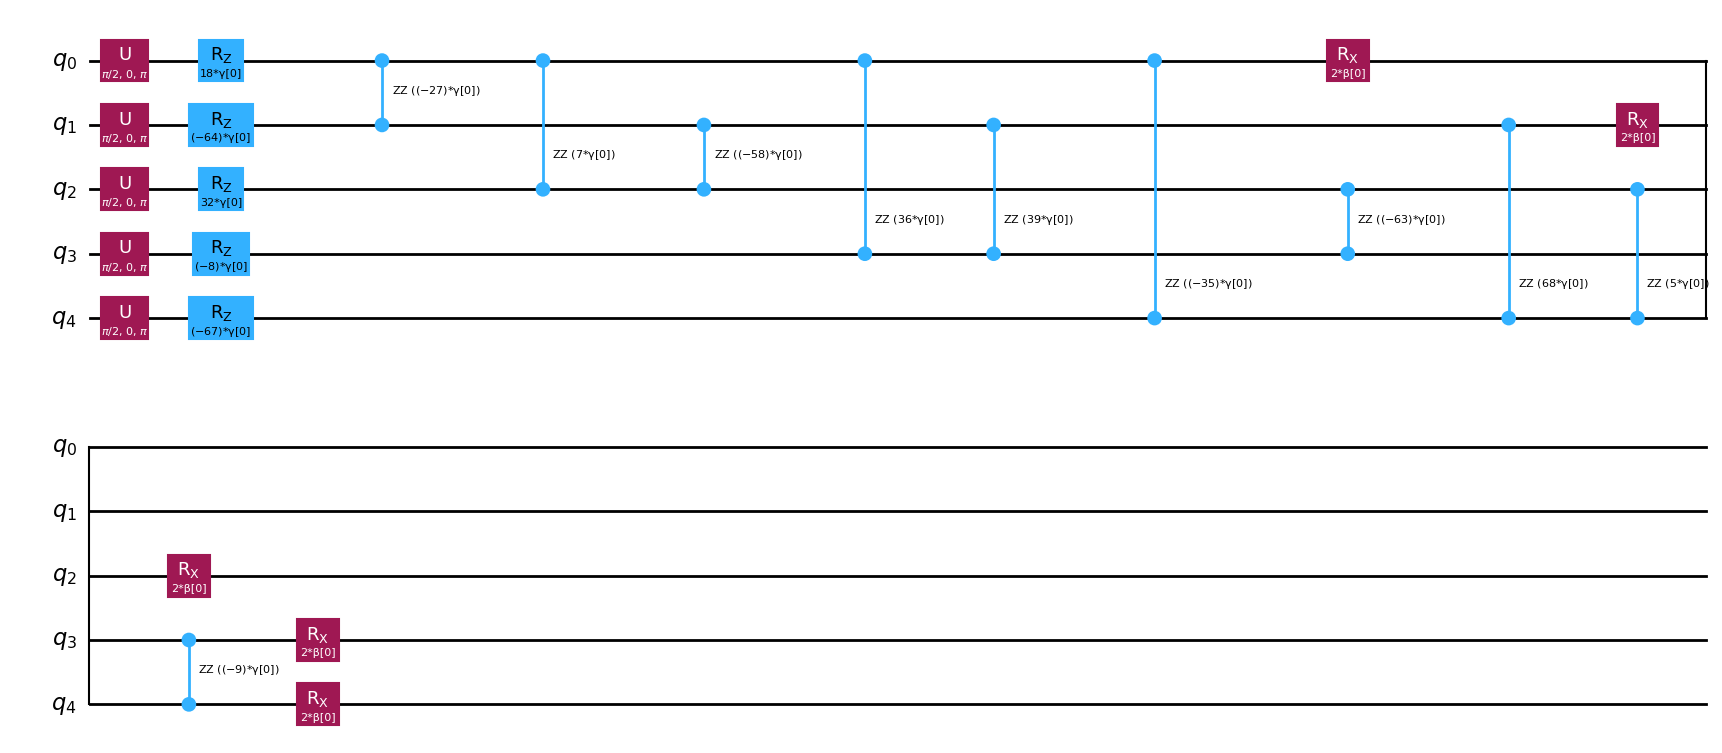

In [15]:
circuito = QAOAAnsatz(cost_operator = Hc, reps = 1)


print(circuito.decompose(reps = 2)) 

fig = circuito.decompose(reps = 2).draw('mpl') #Muestro el circuito
fig.savefig("figures/parte2_introSchnorr_circuito.png", dpi = 150, bbox_inches = "tight")
fig

### **Definición del Algoritmo de QAOA**

In [16]:
def qaoa_algorithm(circuito, Hc, min_method = 'Nelder-Mead'):
    

    parameters = circuito.parameters
    #Obtengo parametros = ParameterView([Parameter(beta[]0),.., Parameter(alfa[0]),.., Parameter[alfa[n - 1]]])

    
    num_parameters = circuito.num_parameters

    p = num_parameters // 2

    #bounds = ([(0, np.pi)]*p + [(0, 2*np.pi)]*p)

    def func_to_minimize(x):

        simulator = StatevectorEstimator() #Instancio el simulador exacto sin ruido

        job = simulator.run([(circuito, Hc, x)])
        result = job.result()[0]
        
        #print(result.data.evs)

        value  = float(result.data.evs)
        return value
    

    x0 = np.asarray([0.0]*num_parameters) #Parametros iniciales

    result = minimize(func_to_minimize, x0, method = min_method)

    optimal = result.x.copy()

    for i in range(p):
        optimal[i] = optimal[i]%np.pi

    for i in range(p):
        optimal[i + p] = optimal[i + p]%(2*np.pi)


    #result = minimize(func_to_minimize, result.x, method = 'COBYLA', bounds = bounds)

    return {param.name: val for param, val in zip(parameters, optimal)}

In [17]:
opt_parameters_dict = qaoa_algorithm(circuito, Hc)

print(opt_parameters_dict)

ncircuito = circuito.assign_parameters(opt_parameters_dict) #Asigno los parametros

print(ncircuito.decompose(reps = 2)) #Muestro el circuito

{'β[0]': np.float64(2.7585106469652256), 'γ[0]': np.float64(0.010043564939717822)}
     ┌────────────┐ ┌─────────────┐                               »
q_0: ┤ U(π/2,0,π) ├─┤ Rz(0.18078) ├──■──────────────■─────────────»
     ├────────────┤ ├─────────────┴┐ │ZZ(-0.27118)  │             »
q_1: ┤ U(π/2,0,π) ├─┤ Rz(-0.64279) ├─■──────────────┼─────────────»
     ├────────────┤ ├─────────────┬┘                │ZZ(0.070305) »
q_2: ┤ U(π/2,0,π) ├─┤ Rz(0.32139) ├─────────────────■─────────────»
     ├────────────┤┌┴─────────────┴┐                              »
q_3: ┤ U(π/2,0,π) ├┤ Rz(-0.080349) ├──────────────────────────────»
     ├────────────┤└┬──────────────┤                              »
q_4: ┤ U(π/2,0,π) ├─┤ Rz(-0.67292) ├──────────────────────────────»
     └────────────┘ └──────────────┘                              »
«                                                               ┌───────────┐ »
«q_0: ────────────────■──────────────────────────■──────────────┤ Rx(5.517) ├─»
«        

In [18]:
def samples_from_parameters (circuit, opt_parameters, Hc, shots):

    sampler = StatevectorSampler() #Declaro un Sampler exacto

    circWithParam = circuit.assign_parameters(opt_parameters)

    circWithParam.measure_all()

    print(circWithParam.decompose(reps = 2))

    
    job = sampler.run([(circWithParam, None)], shots = shots)
    
    result = job.result()[0] 

    counts = result.data.meas.get_counts() #Obtengo un diccionario [bitstring : frecuencia]

    ordered_counts = dict(sorted(counts.items(), key = lambda x: x[1], reverse = True))

    return ordered_counts

In [19]:
shots  = 10_000

In [20]:
results = samples_from_parameters(circuito, opt_parameters_dict, Hc, shots = 10_000)

        ┌────────────┐ ┌─────────────┐                               »
   q_0: ┤ U(π/2,0,π) ├─┤ Rz(0.18078) ├──■──────────────■─────────────»
        ├────────────┤ ├─────────────┴┐ │ZZ(-0.27118)  │             »
   q_1: ┤ U(π/2,0,π) ├─┤ Rz(-0.64279) ├─■──────────────┼─────────────»
        ├────────────┤ ├─────────────┬┘                │ZZ(0.070305) »
   q_2: ┤ U(π/2,0,π) ├─┤ Rz(0.32139) ├─────────────────■─────────────»
        ├────────────┤┌┴─────────────┴┐                              »
   q_3: ┤ U(π/2,0,π) ├┤ Rz(-0.080349) ├──────────────────────────────»
        ├────────────┤└┬──────────────┤                              »
   q_4: ┤ U(π/2,0,π) ├─┤ Rz(-0.67292) ├──────────────────────────────»
        └────────────┘ └──────────────┘                              »
meas: 5/═════════════════════════════════════════════════════════════»
                                                                     »
«                                                                 »
«   q_0: 

In [21]:
print(len(results))
for bitstring, count in results.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

32
Bistring: 10001 -> Counts: 1024
Bistring: 00111 -> Counts: 1001
Bistring: 01100 -> Counts: 1001
Bistring: 01110 -> Counts: 721
Bistring: 00000 -> Counts: 663
Bistring: 11101 -> Counts: 654
Bistring: 00001 -> Counts: 599
Bistring: 00011 -> Counts: 563
Bistring: 11100 -> Counts: 555
Bistring: 01111 -> Counts: 517
Bistring: 00110 -> Counts: 394
Bistring: 01000 -> Counts: 379
Bistring: 11000 -> Counts: 268
Bistring: 11001 -> Counts: 254
Bistring: 01101 -> Counts: 213
Bistring: 10101 -> Counts: 176
Bistring: 10111 -> Counts: 171
Bistring: 10000 -> Counts: 162
Bistring: 00010 -> Counts: 135
Bistring: 00101 -> Counts: 104
Bistring: 01001 -> Counts: 89
Bistring: 11111 -> Counts: 72
Bistring: 00100 -> Counts: 71
Bistring: 11010 -> Counts: 51
Bistring: 10010 -> Counts: 44
Bistring: 11011 -> Counts: 33
Bistring: 10011 -> Counts: 20
Bistring: 11110 -> Counts: 19
Bistring: 10100 -> Counts: 15
Bistring: 10110 -> Counts: 14
Bistring: 01010 -> Counts: 10
Bistring: 01011 -> Counts: 8


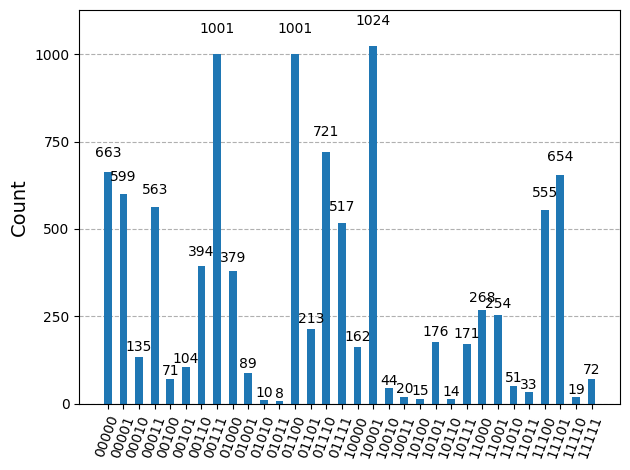

In [22]:
fig = plot_histogram(results)
fig.savefig("figures/parte2_introSchnorr_histograma.png", dpi = 150, bbox_inches = "tight")
fig

In [23]:
def bitstring2vector(bitstrings):

    return np.array([[int(c) for c in reversed(bstring)] for bstring in bitstrings])


def bitstring2latticeVectors(D, state_bistring, step_signs, b_op): 

    bits = bitstring2vector(state_bistring) #Obtengo el vector de bits de la cadena

    aux = np.multiply(step_signs, bits)

    movement = aux @ D.T
    

    vnew = b_op + movement

    return vnew

In [24]:
nD = integerMatrix_to_numpy(D)
vnew = bitstring2latticeVectors(nD, results.keys(), sign_step, b_op)
print(vnew)

[[    -8      5      0      8      3 176979]
 [     2      0     -6      6      6 176994]
 [     4     -2      6     -4      8 176992]
 [    12      1      0     -2      6 176987]
 [     2      4      9      8      0 176993]
 [    -6     -1     -3     -4     11 176978]
 [    -4      8      3      4      2 176996]
 [     4     11     -3      6      0 176991]
 [     0     -5      3      0      9 176975]
 [     6      5     -6     -6      8 176990]
 [     8     -4      0     10      4 176991]
 [     6      9      9     -4      2 176989]
 [     2      6      6      0      3 176972]
 [    -4     10      0     -4      5 176975]
 [    -2      2      0     -8     10 176995]
 [   -10     -6     -3      8      9 176982]
 [    -2     -3     -9     10      7 176977]
 [    -2      1      6     12      1 176976]
 [    10      7      3     10     -2 176988]
 [    -6     -3      0      4      8 176999]
 [     0     13      3     -8      4 176992]
 [     2      2     -9     -2      9 176973]
 [     0  

In [25]:
res_vectors = np.subtract(vnew, t)

for vector in res_vectors:
    print(np.linalg.norm(vector))

14.071247279470288
13.892443989449804
13.601470508735444
13.74772708486752
15.132745950421556
15.231546211727817
15.165750888103101
14.7648230602334
14.66287829861518
14.89966442575134
15.231546211727817
15.297058540778355
15.937377450509228
16.0312195418814
16.492422502470642
17.291616465790582
17.52141546793523
16.34013463836819
16.46207763315433
17.916472867168917
17.52141546793523
17.832554500127006
17.4928556845359
22.58317958127243
21.095023109728988
21.42428528562855
17.944358444926362
18.841443681416774
18.81488772222678
20.396078054371138
18.81488772222678
19.313207915827967


In [26]:
def is_smooth(u, smooth_bound): # Comprobar si es n_smooth
    base = primes[: smooth_bound]
    
    for p in base:
        while u % p == 0:
            u //= p
    
    return u == 1


def vectors2uv_pairs(B, vectors, n):
    first_n_primes = primes[:n]

    B_inv = np.linalg.pinv(B)

    exponentes = np.rint(vectors @ B_inv.T).astype(int) #Obtengo el vector con los exponentes

    u_exp = np.where(exponentes > 0, exponentes, 0) #Obtengo los exponentes positivos
    v_exp = np.where(exponentes < 0, -exponentes, 0) #Obtengo los exponentes negativos y les cambio de signo

    #Obtengo los valores u y v
    u = np.prod(np.power(first_n_primes, u_exp, dtype = object), axis = 1) 
    v = np.prod(np.power(first_n_primes, v_exp, dtype = object), axis = 1)
    

    return np.stack((u, v), axis = 1)

In [27]:
nB = integerMatrix_to_numpy(B)

In [28]:
uv_pairs = vectors2uv_pairs(nB, vnew, n)
print(uv_pairs)

[[776562633 16]
 [1215290846 25]
 [21435888100 441]
 [340139712 7]
 [48620250 1]
 [285311670611 5880]
 [194500845 4]
 [243045684 5]
 [11789738455 243]
 [416713664664 8575]
 [3937140592 81]
 [2381643000 49]
 [48514950 1]
 [9509900499 196]
 [233436821409 4802]
 [5661432406091 116640]
 [327520882997 6750]
 [97060425 2]
 [5881105440 121]
 [10503585169 216]
 [116712415215 2401]
 [42443058438 875]
 [106337949025 2187]
 [48498912 1]
 [533655864 11]
 [8488175652 175]
 [1212977997 25]
 [2182563152 45]
 [11463230904895 236196]
 [530529694772 10935]
 [340122240 7]
 [83338451856 1715]]


In [29]:
def uv_pairs2sr_pairs(uv_pairs, N, n):
    sr_pairs = [tuple(u_v) for u_v in uv_pairs if is_smooth(abs(int(u_v[0]) - N*int(u_v[1])), n)]

    return sr_pairs

sr_pairs = uv_pairs2sr_pairs(uv_pairs, N, smooth_bound)

print(sr_pairs)

[(11789738455, 243)]


A continuacion voy a mostrar una gráfica de distancias y la probabilidad de medirlos

In [30]:
import matplotlib.pyplot as plt

In [31]:
res_vectors = np.subtract(vnew, t)
distances = [float(np.linalg.norm(vector)) for vector in res_vectors]
print(distances)

[14.071247279470288, 13.892443989449804, 13.601470508735444, 13.74772708486752, 15.132745950421556, 15.231546211727817, 15.165750888103101, 14.7648230602334, 14.66287829861518, 14.89966442575134, 15.231546211727817, 15.297058540778355, 15.937377450509228, 16.0312195418814, 16.492422502470642, 17.291616465790582, 17.52141546793523, 16.34013463836819, 16.46207763315433, 17.916472867168917, 17.52141546793523, 17.832554500127006, 17.4928556845359, 22.58317958127243, 21.095023109728988, 21.42428528562855, 17.944358444926362, 18.841443681416774, 18.81488772222678, 20.396078054371138, 18.81488772222678, 19.313207915827967]


In [32]:
probs = [count/shots for count in results.values()]
print(probs)

[0.1024, 0.1001, 0.1001, 0.0721, 0.0663, 0.0654, 0.0599, 0.0563, 0.0555, 0.0517, 0.0394, 0.0379, 0.0268, 0.0254, 0.0213, 0.0176, 0.0171, 0.0162, 0.0135, 0.0104, 0.0089, 0.0072, 0.0071, 0.0051, 0.0044, 0.0033, 0.002, 0.0019, 0.0015, 0.0014, 0.001, 0.0008]


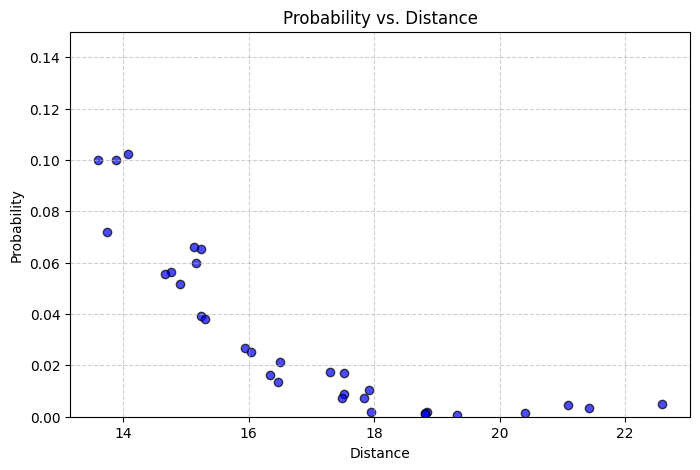

In [33]:
plt.figure(figsize=(8, 5))

# Creating the scatter plot
plt.scatter(distances, probs, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.15) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("figures/parte2_introSchnorr_ProbsDistances.png", dpi = 150, bbox_inches = "tight")
plt.show()